# Bounded Structure Factorization

In the [previous notebook](interparticle_quadratic_verification.ipynb) we verified that a rank-2 decomposition
$M = PC$ with $C = [c;\; c^2]$ can separate the form factor $A(q) = P(q)$ from the
interparticle term $B(q) = P(q)S_1(q)$.

However, rank-2 uses **two** singular values where rank-1 uses one, amplifying noise in the
recovered profile. The **Essence** book (§6.5–6.6) observes that:

1. **Linearly worsened errors** — when rank-2 is applied across the full $q$-range, noise in
   the recovered $A(q)$ grows linearly with the strength of the interparticle term.
2. **Bounded structure factor** — the structure factor $S(q,c) \to 1$ for $q$ beyond a
   boundary $b_1 \approx \pi / R$, so rank-2 is only *needed* in the low-$q$ region.

Two approaches to exploit this boundedness:

- **Synthesized LRF**: Perform rank-2 and rank-1 independently, then splice them with a
  logistic taper around $b_1$. Simple but discards rank-2 information at high $q$.
- **Bounded LRF** (the true approach): Perform a single rank-2 decomposition, then **clamp**
  $B(q)$ to lie within a physics-derived envelope $\pm A(q)/(c_1(qLR)^2)$ and **redistribute**
  the excess into $A(q)$. This preserves the rank-2 structure while suppressing noise.

**Structure**:
1. **Theory** — The bound derivation from $\Phi(x)$ and the coerce_bounds algorithm
2. **Synthetic verification** — Compare rank-1, full rank-2, synthesized LRF, and bounded LRF
3. **Real data** — Apply to SAMPLE3 (glucose isomerase)

---
## Part 1: The bound derivation and the coerce_bounds algorithm

### Where does $S(q,c) \to 1$?

For a solid sphere of radius $R$, the Debye structure factor (first-order) is

$$S_0(q) = 1 - K\,\Phi(2qR)$$

where $\Phi(x) = 3(\sin x - x\cos x)/x^3$ is the sphere form factor amplitude.

### Derivation of the $1/(qLR)^2$ bound

For large $x$, writing $\sin x - x\cos x$ in amplitude form gives
$|\sin x - x\cos x| \leq \sqrt{1+x^2}$, so

$$|\Phi(x)| = \frac{3\sqrt{1+x^2}}{x^3} \;\xrightarrow{x \gg 1}\; \frac{3}{x^2}$$

The interparticle term $B(q) = A(q)\cdot S_1(q)$ where $S_1(q) = -K\,\Phi(2qLR)$, so

$$|B(q)| \leq A(q) \cdot \frac{3K}{(2qLR)^2} = A(q)\cdot \frac{3K}{4(qLR)^2}$$

The constant $3K/4$ is absorbed into the **fitted** parameter $L$, giving the working bound:

$$|B(q)| \leq \frac{A(q)}{c_1\,(qLR)^2}$$

### The coerce_bounds algorithm (from `BoundedLrfSolver.py`)

1. Perform a single rank-2 pseudoinverse: $P = M\,C^+$, yielding $A(q), B(q)$
2. Estimate $R_g$, compute $R = \sqrt{5/3}\,R_g$
3. Fit $K, L$ by minimising $\|{-K\,\Phi(2qLR)\cdot A(q) - B(q)}\|^2$
4. Compute envelope: `bound = 1/(q·L·R)²`, then `bq_bound = bound · A(q)/c₁`
5. Clamp: $B'(q) = \text{clip}(B(q),\; -\text{bq\_bound},\; +\text{bq\_bound})$
6. Redistribute: $A'(q) = A(q) + [B(q) - B'(q)]\cdot c_2/c_1$

Step 6 ensures $A'c_1 + B'c_2 = Ac_1 + Bc_2$ (peak-frame intensity is conserved).

### Why rank-2 amplifies noise

In the pseudoinverse $P = MC^+$ the condition number of $C = [c;\; c^2]$ grows with rank.
The $c^2$ row is nearly collinear with $c$ for a peaked elution profile, so $C^+$ amplifies noise.
Bounded LRF addresses this by constraining $B(q)$ rather than discarding rank-2 information.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from molass.SAXS.Models.Formfactors import homogeneous_sphere
from molass.SAXS.Theory.DjKinning1984 import S0, P0
from molass.SAXS.Theory.SolidSphere import phi, get_boundary_params_simple
from molass.SEC.Models.Simple import gaussian

np.random.seed(42)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

C:\Users\takahashi\GitHub\molass-library\molass\SAXS\Theory\SolidSphere.py:196: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
  ax.set_title("Periodic appearances in $ \Phi(qR)^2 $ and $cos(qR)^2$", fontsize=20)
C:\Users\takahashi\GitHub\molass-library\molass\SAXS\Theory\SolidSphere.py:198: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
  ax.plot(qv, phi(qv, R)**2, label='$ \Phi(qR)^2 $')


b1 = 0.0695, b2 = 0.1043 (1/Å)


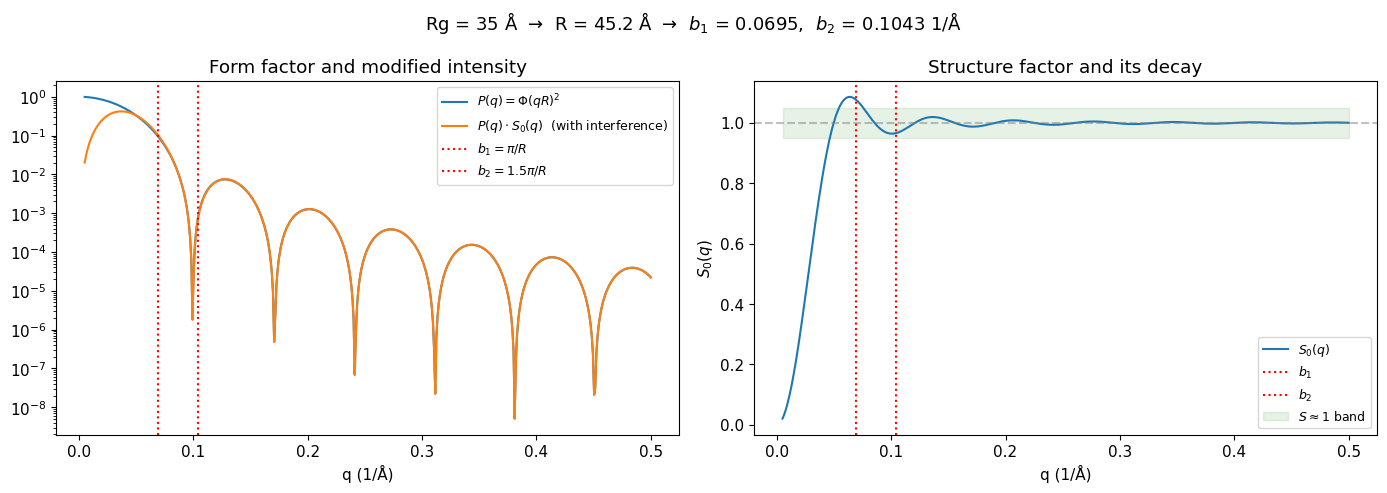

In [2]:
# --- Visualise the q-boundary for a sphere with Rg = 35 Å ---
Rg = 35
R = np.sqrt(5/3) * Rg
qv = np.linspace(0.005, 0.5, 500)

b1, b2, k = get_boundary_params_simple(Rg)

# Form factor P(q) and structure factor S0(q)
Pq = phi(qv, R)**2
S0q = S0(qv, R)
Bq_over_Aq = -(S0q - 1)   # = phi(2qR), the ratio B(q)/A(q)

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(14, 5))

ax1.set_title("Form factor and modified intensity")
ax1.set_yscale('log')
ax1.plot(qv, Pq, label='$P(q) = \\Phi(qR)^2$')
ax1.plot(qv, Pq * S0q, label='$P(q) \\cdot S_0(q)$  (with interference)')
for b, lbl in [(b1, '$b_1 = \\pi/R$'), (b2, '$b_2 = 1.5\\pi/R$')]:
    ax1.axvline(b, ls=':', color='red', label=lbl)
ax1.legend(fontsize=9)
ax1.set_xlabel('q (1/Å)')

ax2.set_title("Structure factor and its decay")
ax2.plot(qv, S0q, label='$S_0(q)$')
ax2.axhline(1, ls='--', color='gray', alpha=0.5)
for b, lbl in [(b1, '$b_1$'), (b2, '$b_2$')]:
    ax2.axvline(b, ls=':', color='red', label=lbl)
ax2.fill_between(qv, 0.95, 1.05, alpha=0.1, color='green', label='$S \\approx 1$ band')
ax2.legend(fontsize=9)
ax2.set_xlabel('q (1/Å)')
ax2.set_ylabel('$S_0(q)$')

fig.suptitle(f"Rg = {Rg} Å  →  R = {R:.1f} Å  →  $b_1$ = {b1:.4f},  $b_2$ = {b2:.4f} 1/Å", fontsize=13)
fig.tight_layout()
print(f"b1 = {b1:.4f}, b2 = {b2:.4f} (1/Å)")

In [3]:
# --- Error amplification: condition number of C vs q-range ---
# Show how the pseudoinverse amplifies noise when rank-2 is used over the full range

x = np.arange(300)
c_profile = gaussian(x, 1, 150, 30)

# Build C matrices for rank-1 and rank-2
C1 = c_profile.reshape(1, -1)
C2 = np.vstack([c_profile, c_profile**2])

cond1 = np.linalg.cond(C1)
cond2 = np.linalg.cond(C2)
print(f"Condition number  rank-1: {cond1:.1f}")
print(f"Condition number  rank-2: {cond2:.1f}")
print(f"Amplification factor: {cond2/cond1:.1f}x")

# Show the singular values
s1 = np.linalg.svd(C1, compute_uv=False)
s2 = np.linalg.svd(C2, compute_uv=False)
print(f"\nRank-1 singular values: {s1}")
print(f"Rank-2 singular values: {s2}")
print(f"Rank-2 σ₁/σ₂ = {s2[0]/s2[1]:.1f}")

Condition number  rank-1: 1.0
Condition number  rank-2: 8.4
Amplification factor: 8.4x

Rank-1 singular values: [7.2920241]
Rank-2 singular values: [9.46020153 1.13032151]
Rank-2 σ₁/σ₂ = 8.4


---
## Part 2: Synthetic — Four Recovery Strategies

We build synthetic SEC-SAXS data:
- $A(q) = \Phi(qR)^2$ (homogeneous sphere, Rg = 35 Å)
- $B(q) = A(q) \cdot S_1(q)$ where $S_1(q) = -(S_0(q) - 1)$
- Gaussian elution profile $c(t)$
- $M = P \cdot C + \varepsilon$ with controlled noise

We compare four recovery strategies:
1. **Rank-1** — ignores interparticle effects ($P = M \cdot c^+$)
2. **Full rank-2** (naïve LRF) — applies $C = [c;\; c^2]$ across the entire $q$-range
3. **Synthesized LRF** — rank-2 for $q < b_1$, rank-1 for $q \geq b_1$, with logistic taper
4. **Bounded LRF** — single rank-2, then clamp $B(q)$ within $1/(qLR)^2$ envelope and redistribute

In [4]:
# --- Build synthetic data ---
Rg_true = 35
R_true = np.sqrt(5/3) * Rg_true
q = np.linspace(0.005, 0.4, 400)
n_frames = 300

# True profiles
A_true = phi(q, R_true)**2                     # form factor
S1_true = -(S0(q, R_true) - 1)                 # = phi(2qR), positive at low q
B_true = A_true * S1_true                       # interparticle term

# Elution profile
x = np.arange(n_frames)
c_true = gaussian(x, 1, 150, 30)

# Concentration matrix for rank-2
C_full = np.vstack([c_true, c_true**2])         # (2 x n)

# Data matrix M = P @ C + noise
P_true = np.column_stack([A_true, B_true])      # (m x 2)
M_clean = P_true @ C_full

noise_level = 0.01
noise = noise_level * np.random.randn(*M_clean.shape) * np.abs(M_clean).max()
M_noisy = M_clean + noise

print(f"M shape: {M_noisy.shape}")
print(f"SNR (peak): {np.abs(M_clean).max() / (noise_level * np.abs(M_clean).max()):.0f}")

# q-boundary from the solid sphere model
b1, b2, k_logistic = get_boundary_params_simple(Rg_true)
print(f"\nBoundary: b1 = {b1:.4f}, b2 = {b2:.4f} (1/Å)")
idx_b1 = np.searchsorted(q, b1)
idx_b2 = np.searchsorted(q, b2)
print(f"Boundary indices: b1 → {idx_b1}, b2 → {idx_b2} out of {len(q)}")

M shape: (400, 300)
SNR (peak): 100

Boundary: b1 = 0.0695, b2 = 0.1043 (1/Å)
Boundary indices: b1 → 66, b2 → 101 out of 400


In [5]:
# --- Four recovery strategies ---
from scipy.optimize import minimize

j_peak = np.argmax(c_true)
c1 = c_true[j_peak]      # peak concentration
c2 = c_true[j_peak]**2   # peak concentration squared

# 1. Rank-1: ignores interparticle term
C1 = c_true.reshape(1, -1)
P_rank1 = M_noisy @ np.linalg.pinv(C1)
A_rank1 = P_rank1[:, 0]

# 2. Full rank-2 (naïve LRF)
P_rank2 = M_noisy @ np.linalg.pinv(C_full)
A_rank2 = P_rank2[:, 0]
B_rank2 = P_rank2[:, 1]

# 3. Synthesized LRF: logistic blend of rank-2 (low-q) and rank-1 (high-q)
w = 1 / (1 + np.exp(-k_logistic * (q - b1)))      # 0 → rank-2, 1 → rank-1
A_synth = (1 - w) * A_rank2 + w * A_rank1

# 4. Bounded LRF: single rank-2 then coerce_bounds
# 4a. Estimate Rg from Guinier fit on rank-2 A(q)
def guinier_rg(q_vals, I_vals):
    """Fit Guinier: ln(I) = ln(I0) - Rg²/3 * q².  Return Rg."""
    mask = I_vals > 0
    if mask.sum() < 3:
        return np.nan
    coeffs = np.polyfit(q_vals[mask]**2, np.log(I_vals[mask]), 1)
    Rg2 = -3 * coeffs[0]
    return np.sqrt(Rg2) if Rg2 > 0 else np.nan

rg_est = guinier_rg(q[q < 0.05], A_rank2[q < 0.05])
R_est = np.sqrt(5/3) * rg_est

# 4b. Fit K, L by matching B(q) ≈ -K·Φ(2qLR)·A(q)
#     K sign is unconstrained (depends on B(q) sign convention)
fit_mask = (q > 0.01) & (q < 0.2)
q_fit, A_fit, B_fit = q[fit_mask], A_rank2[fit_mask], B_rank2[fit_mask]

def kl_objective(p):
    K_, L_ = p
    h_B = -K_ * phi(q_fit, 2*L_*R_est) * A_fit
    return np.mean((h_B - B_fit)**2)

ret = minimize(kl_objective, (-0.5, 2.0))
K_fit, L_fit = ret.x

# 4c. Refine L for the bound envelope (like legacy objective2)
#     The bound must contain |B(q)|, with tighter fit to the upper envelope
from bisect import bisect_right
j2 = np.argmax(np.abs(B_rank2[fit_mask]))
i2 = bisect_right(q, 0.2)
slice2 = slice(j2, i2)
q_env = q[slice2]
aq_env = A_rank2[slice2]
bq_env = B_rank2[slice2]

h_bq_env = -K_fit * phi(q_env, 2*L_fit*R_est) * aq_env / c1
upper_bq = np.max([np.abs(bq_env / c1), np.abs(h_bq_env)], axis=0)

def bound_objective(p):
    L, = p
    bound_env = 1/(q_env * L * R_est)**2 * aq_env / c1
    diff = upper_bq - bound_env
    pos = diff[diff > 0]
    neg = diff[diff <= 0]
    return 99*np.mean(pos**2) if len(pos) > 0 else 0 + np.mean(neg**2) if len(neg) > 0 else 0

ret2 = minimize(bound_objective, (abs(L_fit),))
L_final = ret2.x[0]

# 4d. coerce_bounds with refined L
bound = 1 / (q * L_final * R_est)**2
bq_bound = bound * A_rank2 / c1
B_clamped = np.clip(B_rank2, -bq_bound, bq_bound)
A_bounded = A_rank2 + (B_rank2 - B_clamped) * c2 / c1

n_clamped = np.sum(np.abs(B_rank2) > bq_bound)
print("Recovery complete.")
print(f"  Rg est: {rg_est:.2f} Å  (true: {Rg_true})")
print(f"  K fit: {K_fit:.4f},  L fit (initial): {L_fit:.4f},  L final: {L_final:.4f}")
print(f"  B(q) clamped at {n_clamped} / {len(q)} q-points")

Recovery complete.
  Rg est: 36.26 Å  (true: 35)
  K fit: -0.9979,  L fit (initial): 0.9690,  L final: 0.9057
  B(q) clamped at 335 / 400 q-points



Region                        Rank-1   Full R-2      Synth    Bounded
--------------------------------------------------------------------
low-q (< b1)                0.363303   0.009444   0.008872   0.009234
transition (b1–b2)          0.003543   0.011089   0.003677   0.004283
high-q (≥ b2)               0.002640   0.011716   0.002639   0.003606
full range                  0.147596   0.011318   0.004402   0.005039


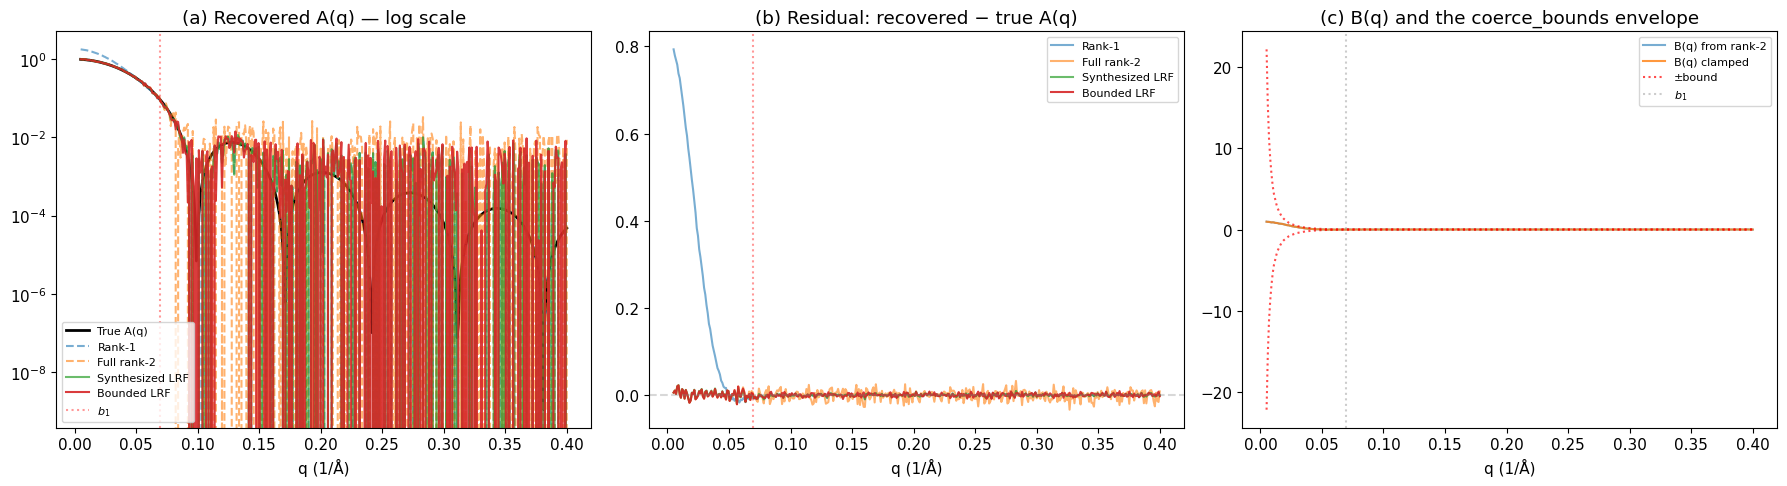

In [6]:
# --- Compare recovered A(q) profiles ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

methods = [
    (A_rank1, 'Rank-1', '--', 0.6),
    (A_rank2, 'Full rank-2', '--', 0.6),
    (A_synth, 'Synthesized LRF', '-', 0.7),
    (A_bounded, 'Bounded LRF', '-', 0.9),
]

# (a) Log-scale overlay
ax = axes[0]
ax.set_title("(a) Recovered A(q) — log scale")
ax.set_yscale('log')
ax.plot(q, A_true, 'k-', lw=2, label='True A(q)')
for A, label, ls, alpha in methods:
    ax.plot(q, A, ls, alpha=alpha, label=label)
ax.axvline(b1, ls=':', color='red', alpha=0.4, label='$b_1$')
ax.legend(fontsize=8)
ax.set_xlabel('q (1/Å)')

# (b) Residuals
ax = axes[1]
ax.set_title("(b) Residual: recovered − true A(q)")
for A, label, ls, alpha in methods:
    ax.plot(q, A - A_true, alpha=alpha, label=label)
ax.axhline(0, color='gray', ls='--', alpha=0.3)
ax.axvline(b1, ls=':', color='red', alpha=0.4)
ax.legend(fontsize=8)
ax.set_xlabel('q (1/Å)')

# (c) The bounding envelope on B(q)
ax = axes[2]
ax.set_title("(c) B(q) and the coerce_bounds envelope")
ax.plot(q, B_rank2, alpha=0.6, label='B(q) from rank-2')
ax.plot(q, B_clamped, alpha=0.8, label='B(q) clamped')
ax.plot(q, bq_bound, ':', color='red', alpha=0.7, label='±bound')
ax.plot(q, -bq_bound, ':', color='red', alpha=0.7)
ax.axvline(b1, ls=':', color='gray', alpha=0.4, label='$b_1$')
ax.legend(fontsize=8)
ax.set_xlabel('q (1/Å)')

fig.tight_layout()

# Quantitative comparison: RMS error in different q-regions
def rms(y): return np.sqrt(np.mean(y**2))

regions = {
    'low-q (< b1)': q < b1,
    'transition (b1–b2)': (q >= b1) & (q < b2),
    'high-q (≥ b2)': q >= b2,
    'full range': np.ones(len(q), dtype=bool)
}

print(f"\n{'Region':<25s} {'Rank-1':>10s} {'Full R-2':>10s} {'Synth':>10s} {'Bounded':>10s}")
print("-" * 68)
for name, mask in regions.items():
    e1 = rms(A_rank1[mask] - A_true[mask])
    e2 = rms(A_rank2[mask] - A_true[mask])
    es = rms(A_synth[mask] - A_true[mask])
    eb = rms(A_bounded[mask] - A_true[mask])
    print(f"{name:<25s} {e1:10.6f} {e2:10.6f} {es:10.6f} {eb:10.6f}")

Guinier Rg estimates (true Rg = 35.0 Å):
  True A(q):       36.29 Å
  Rank-1:          45.57 Å  (Δ = 30.21%)
  Full rank-2:     36.26 Å  (Δ = 3.60%)
  Synthesized LRF: 36.23 Å  (Δ = 3.51%)
  Bounded LRF:     36.26 Å  (Δ = 3.60%)


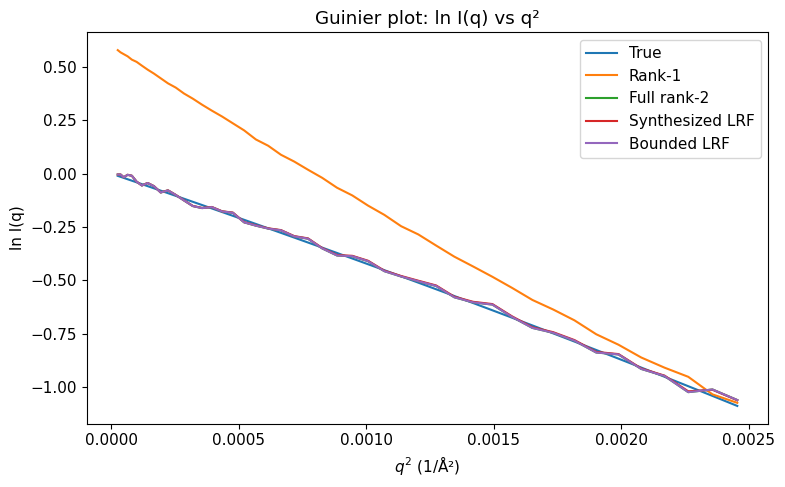

In [7]:
# --- Guinier comparison: all four strategies ---
q_guinier_max = 0.05
mask_g = q < q_guinier_max

rg_true = guinier_rg(q[mask_g], A_true[mask_g])
rg_r1 = guinier_rg(q[mask_g], A_rank1[mask_g])
rg_r2 = guinier_rg(q[mask_g], A_rank2[mask_g])
rg_syn = guinier_rg(q[mask_g], A_synth[mask_g])
rg_bd = guinier_rg(q[mask_g], A_bounded[mask_g])

print(f"Guinier Rg estimates (true Rg = {Rg_true:.1f} Å):")
print(f"  True A(q):       {rg_true:.2f} Å")
print(f"  Rank-1:          {rg_r1:.2f} Å  (Δ = {abs(rg_r1 - Rg_true)/Rg_true*100:.2f}%)")
print(f"  Full rank-2:     {rg_r2:.2f} Å  (Δ = {abs(rg_r2 - Rg_true)/Rg_true*100:.2f}%)")
print(f"  Synthesized LRF: {rg_syn:.2f} Å  (Δ = {abs(rg_syn - Rg_true)/Rg_true*100:.2f}%)")
print(f"  Bounded LRF:     {rg_bd:.2f} Å  (Δ = {abs(rg_bd - Rg_true)/Rg_true*100:.2f}%)")

fig, ax = plt.subplots(figsize=(8, 5))
ax.set_title("Guinier plot: ln I(q) vs q²")
for vals, label in [(A_true, 'True'), (A_rank1, 'Rank-1'),
                     (A_rank2, 'Full rank-2'), (A_synth, 'Synthesized LRF'),
                     (A_bounded, 'Bounded LRF')]:
    m = mask_g & (vals > 0)
    ax.plot(q[m]**2, np.log(vals[m]), label=label)
ax.set_xlabel('$q^2$ (1/Å²)')
ax.set_ylabel('ln I(q)')
ax.legend()
fig.tight_layout()

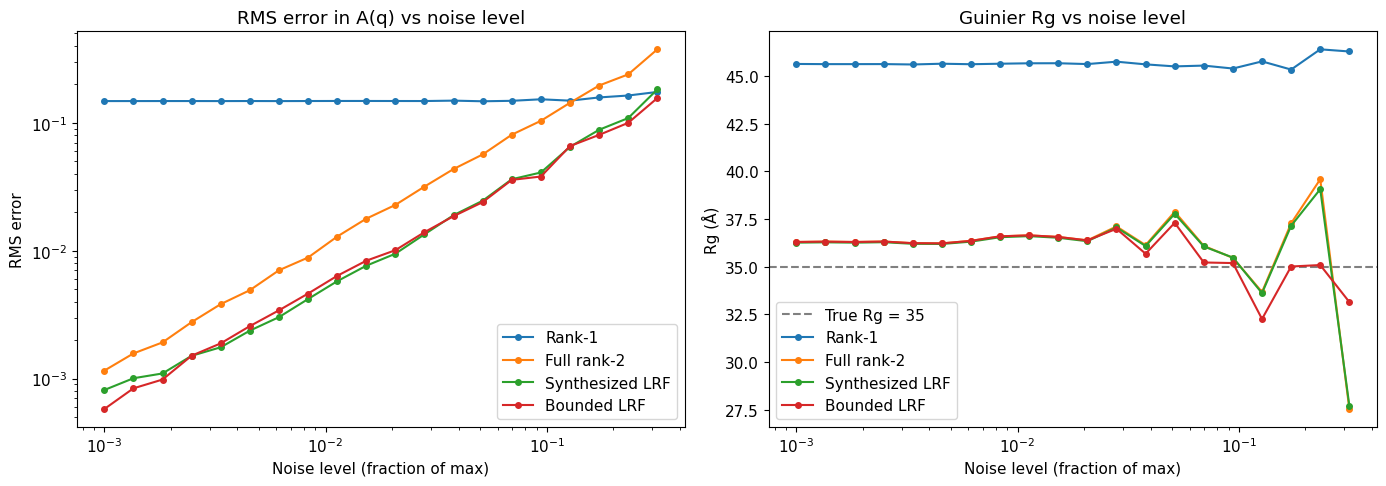

In [8]:
# --- Noise sweep: how do the four strategies degrade? ---
noise_levels = np.logspace(-3, -0.5, 20)
method_names = ['Rank-1', 'Full rank-2', 'Synthesized LRF', 'Bounded LRF']
results = {m: [] for m in method_names}
rg_results = {m: [] for m in method_names}

Cinv_full = np.linalg.pinv(C_full)
Cinv_1 = np.linalg.pinv(C1)

for nl in noise_levels:
    eps = nl * np.abs(M_clean).max() * np.random.randn(*M_clean.shape)
    M_trial = M_clean + eps

    P1 = M_trial @ Cinv_1
    P2 = M_trial @ Cinv_full

    # Synthesized
    A_s = (1 - w) * P2[:, 0] + w * P1[:, 0]

    # Bounded: coerce_bounds on this trial's rank-2
    aq_t, bq_t = P2[:, 0], P2[:, 1]
    bound_t = 1 / (q * L_fit * R_est)**2
    bqb_t = bound_t * aq_t / c1
    bq_clamp = np.clip(bq_t, -bqb_t, bqb_t)
    A_b = aq_t + (bq_t - bq_clamp) * c2 / c1

    results['Rank-1'].append(rms(P1[:, 0] - A_true))
    results['Full rank-2'].append(rms(P2[:, 0] - A_true))
    results['Synthesized LRF'].append(rms(A_s - A_true))
    results['Bounded LRF'].append(rms(A_b - A_true))

    for name, A in [('Rank-1', P1[:,0]), ('Full rank-2', P2[:,0]),
                     ('Synthesized LRF', A_s), ('Bounded LRF', A_b)]:
        rg_results[name].append(guinier_rg(q[mask_g], A[mask_g]))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.set_title("RMS error in A(q) vs noise level")
ax1.set_xscale('log'); ax1.set_yscale('log')
for m, vals in results.items():
    ax1.plot(noise_levels, vals, 'o-', label=m, markersize=4)
ax1.set_xlabel('Noise level (fraction of max)')
ax1.set_ylabel('RMS error')
ax1.legend()

ax2.set_title("Guinier Rg vs noise level")
ax2.set_xscale('log')
ax2.axhline(Rg_true, ls='--', color='gray', label=f'True Rg = {Rg_true}')
for m, vals in rg_results.items():
    ax2.plot(noise_levels, vals, 'o-', label=m, markersize=4)
ax2.set_xlabel('Noise level (fraction of max)')
ax2.set_ylabel('Rg (Å)')
ax2.legend()

fig.tight_layout()

---
### The key difference: what happens near $b_1$

Synthesized LRF blends toward rank-1 around $b_1$, implicitly forcing $B(q) \to 0$.
Bounded LRF keeps $B(q)$ nonzero wherever it lies within the $1/(qLR)^2$ envelope.

In the transition region ($b_1 \lesssim q \lesssim b_2$), the true $S_1(q)$ is still
declining — it hasn't reached zero yet. Bounded LRF captures this declining tail;
Synthesized LRF discards it.

RMS A(q) error in transition region (b1–b2):
  Full rank-2:     0.011089
  Synthesized LRF: 0.003677
  Bounded LRF:     0.004283
  Rank-1:          0.003543


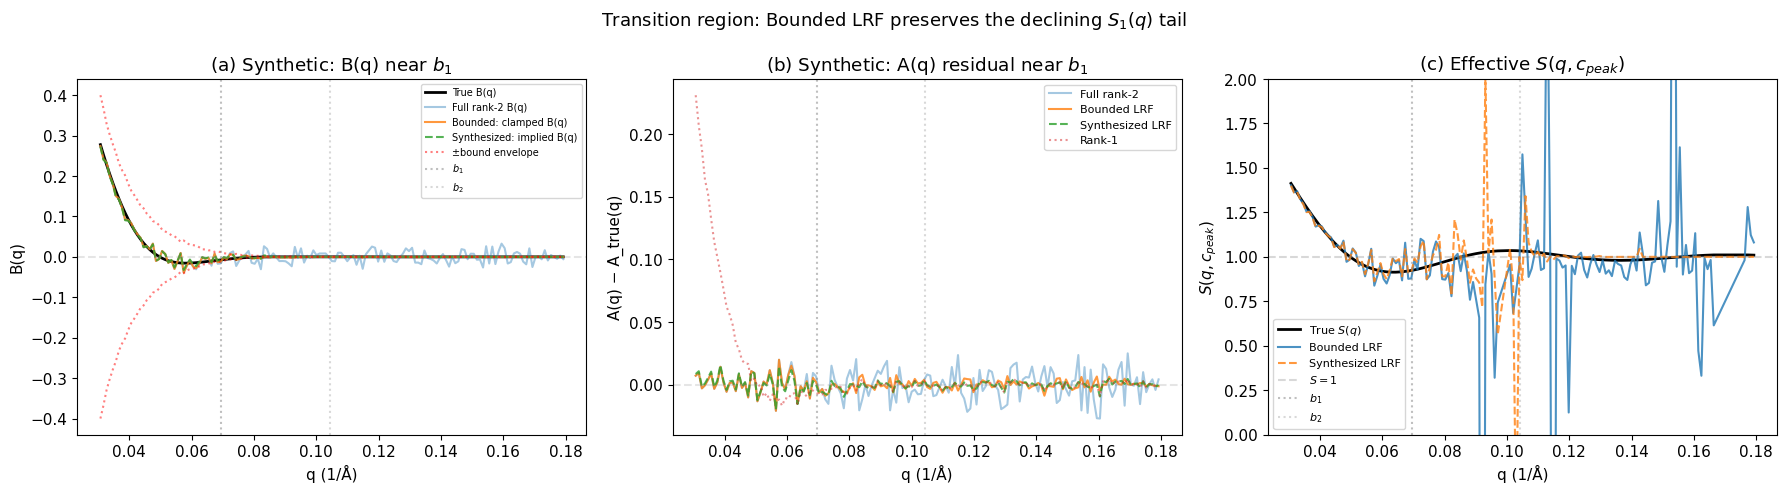

In [9]:
# --- Zoom into the transition region: Synthesized vs Bounded ---
# What B(q) does each method imply in the region around b1?

# Synthesized LRF: the implied B(q) from the logistic blend
B_synth_implied = B_rank2 * (1 - w)  # logistic suppresses B toward zero

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- (a) B(q) in transition region (synthetic data) ---
trans = (q > 0.03) & (q < 0.18)
ax = axes[0]
ax.set_title("(a) Synthetic: B(q) near $b_1$")
ax.plot(q[trans], B_true[trans], 'k-', lw=2, label='True B(q)')
ax.plot(q[trans], B_rank2[trans], alpha=0.4, label='Full rank-2 B(q)')
ax.plot(q[trans], B_clamped[trans], '-', alpha=0.8, label='Bounded: clamped B(q)')
ax.plot(q[trans], B_synth_implied[trans], '--', alpha=0.8, label='Synthesized: implied B(q)')
ax.plot(q[trans], bq_bound[trans], ':', color='red', alpha=0.5, label='±bound envelope')
ax.plot(q[trans], -bq_bound[trans], ':', color='red', alpha=0.5)
ax.axvline(b1, ls=':', color='gray', alpha=0.5, label='$b_1$')
ax.axvline(b2, ls=':', color='gray', alpha=0.3, label='$b_2$')
ax.axhline(0, color='gray', ls='--', alpha=0.2)
ax.legend(fontsize=7)
ax.set_xlabel('q (1/Å)')
ax.set_ylabel('B(q)')

# --- (b) Resulting A(q) error in transition region ---
ax = axes[1]
ax.set_title("(b) Synthetic: A(q) residual near $b_1$")
ax.plot(q[trans], A_rank2[trans] - A_true[trans], alpha=0.4, label='Full rank-2')
ax.plot(q[trans], A_bounded[trans] - A_true[trans], '-', alpha=0.8, label='Bounded LRF')
ax.plot(q[trans], A_synth[trans] - A_true[trans], '--', alpha=0.8, label='Synthesized LRF')
ax.plot(q[trans], A_rank1[trans] - A_true[trans], ':', alpha=0.5, label='Rank-1')
ax.axvline(b1, ls=':', color='gray', alpha=0.5)
ax.axvline(b2, ls=':', color='gray', alpha=0.3)
ax.axhline(0, color='gray', ls='--', alpha=0.2)
ax.legend(fontsize=8)
ax.set_xlabel('q (1/Å)')
ax.set_ylabel('A(q) − A_true(q)')

# --- (c) Effective S(q) comparison ---
# S_eff(q) = 1 + B(q)/A(q) · c2/c1  (what the peak-frame intensity sees)
# Use only where A_true is sizable to avoid division artifacts
safe_mask = trans & (A_true > 1e-4)
safe_A_true = A_true[safe_mask]
S_true_v = 1 + B_true[safe_mask] / safe_A_true * c2 / c1

safe_A_bd = np.where(np.abs(A_bounded[safe_mask]) > 1e-6, A_bounded[safe_mask], 1e-6)
S_bounded_v = 1 + B_clamped[safe_mask] / safe_A_bd * c2 / c1

safe_A_syn = np.where(np.abs(A_synth[safe_mask]) > 1e-6, A_synth[safe_mask], 1e-6)
S_synth_v = 1 + B_synth_implied[safe_mask] / safe_A_syn * c2 / c1

ax = axes[2]
ax.set_title("(c) Effective $S(q, c_{peak})$")
ax.plot(q[safe_mask], S_true_v, 'k-', lw=2, label='True $S(q)$')
ax.plot(q[safe_mask], S_bounded_v, '-', alpha=0.8, label='Bounded LRF')
ax.plot(q[safe_mask], S_synth_v, '--', alpha=0.8, label='Synthesized LRF')
ax.axhline(1, color='gray', ls='--', alpha=0.3, label='$S = 1$')
ax.axvline(b1, ls=':', color='gray', alpha=0.5, label='$b_1$')
ax.axvline(b2, ls=':', color='gray', alpha=0.3, label='$b_2$')
ax.set_ylim(0, 2.0)
ax.legend(fontsize=8)
ax.set_xlabel('q (1/Å)')
ax.set_ylabel('$S(q, c_{peak})$')

fig.suptitle("Transition region: Bounded LRF preserves the declining $S_1(q)$ tail", fontsize=13)
fig.tight_layout()

# Quantify: RMS of A(q) error in b1–b2 transition
trans_mask = (q >= b1) & (q < b2)
print(f"RMS A(q) error in transition region (b1–b2):")
print(f"  Full rank-2:     {rms(A_rank2[trans_mask] - A_true[trans_mask]):.6f}")
print(f"  Synthesized LRF: {rms(A_synth[trans_mask] - A_true[trans_mask]):.6f}")
print(f"  Bounded LRF:     {rms(A_bounded[trans_mask] - A_true[trans_mask]):.6f}")
print(f"  Rank-1:          {rms(A_rank1[trans_mask] - A_true[trans_mask]):.6f}")

---
## Part 3: Real Data — SAMPLE3 (Glucose Isomerase)

SAMPLE3 has Rg ≈ 33 Å (from rank-2 in the previous notebook), so $b_1 \approx \pi / R$ where
$R = \sqrt{5/3} \cdot 33 \approx 42.6$ Å, giving $b_1 \approx 0.074$ 1/Å.

We apply the four-strategy comparison to the real data:
1. Load the data and extract the UV-based concentration profile
2. Rank-1, full rank-2, synthesized LRF, and bounded LRF recovery
3. Guinier Rg comparison

In [10]:
# --- Load SAMPLE3 real data ---
import os, glob
from molass_data import SAMPLE3

dat_files = sorted(glob.glob(os.path.join(SAMPLE3, "PREFIX3_*.dat")))
first = np.loadtxt(dat_files[0])
q_real = first[:, 0]
n_q = len(q_real)
n_frames = len(dat_files)

M_real = np.zeros((n_q, n_frames))
E_real = np.zeros((n_q, n_frames))
for j, f in enumerate(dat_files):
    d = np.loadtxt(f)
    M_real[:, j] = d[:, 1]
    E_real[:, j] = d[:, 2]

# Load UV profile (concentration proxy)
# The UV file is space-separated (not tab), with 2 header lines
uv_file = os.path.join(SAMPLE3, "PREFIX3_UV.txt")
uv_array = np.loadtxt(uv_file, skiprows=2)   # skip "Spectrometers:..." and ">>>> Data Start <<<<"
wavelengths = uv_array[:, 0]

# Pick 280 nm (protein absorbance)
idx_280 = np.argmin(np.abs(wavelengths - 280))
uv_280 = uv_array[idx_280, 1:]

# Downsample 2:1 if UV has more columns than SAXS frames
if len(uv_280) >= 2 * n_frames:
    uv_profile = uv_280[::2][:n_frames]
else:
    uv_profile = uv_280[:n_frames]
uv_profile = uv_profile - np.min(uv_profile)
uv_profile = uv_profile / np.max(uv_profile)

print(f"M_real: {M_real.shape}")
print(f"q range: [{q_real[0]:.4f}, {q_real[-1]:.4f}]")
print(f"UV array shape: {uv_array.shape} (wavelengths × (1+frames))")
print(f"UV profile: {len(uv_profile)} points, peak at frame {np.argmax(uv_profile)}")

M_real: (775, 360)
q range: [0.0075, 0.4192]
UV array shape: (318, 721) (wavelengths × (1+frames))
UV profile: 360 points, peak at frame 200


In [11]:
# --- Apply four recovery strategies to SAMPLE3 ---

# Use the peak region for better conditioning
peak_idx = np.argmax(uv_profile)
half_max = uv_profile[peak_idx] / 2
left = np.where(uv_profile[:peak_idx] < half_max)[0]
right = np.where(uv_profile[peak_idx:] < half_max)[0]
f_start = left[-1] if len(left) > 0 else 0
f_end = peak_idx + right[0] if len(right) > 0 else n_frames - 1

c_peak = uv_profile[f_start:f_end+1]
M_peak = M_real[:, f_start:f_end+1]
print(f"Peak region: frames {f_start}–{f_end} ({len(c_peak)} frames)")

# C matrices
C1_real = c_peak.reshape(1, -1)
C2_real = np.vstack([c_peak, c_peak**2])
j_peak_real = np.argmax(c_peak)
c1_real = c_peak[j_peak_real]
c2_real = c_peak[j_peak_real]**2

# 1. Rank-1
A_r1_real = (M_peak @ np.linalg.pinv(C1_real))[:, 0]

# 2. Full rank-2
P_r2_real = M_peak @ np.linalg.pinv(C2_real)
A_r2_real = P_r2_real[:, 0]
B_r2_real = P_r2_real[:, 1]

# 3. Synthesized LRF
Rg_est = 33.0
R_est_real = np.sqrt(5/3) * Rg_est
b1_real, b2_real, k_real = get_boundary_params_simple(Rg_est)
w_real = 1 / (1 + np.exp(-k_real * (q_real - b1_real)))
A_synth_real = (1 - w_real) * A_r2_real + w_real * A_r1_real

# 4. Bounded LRF: fit K, L on real data, then coerce_bounds
rg_from_r2 = guinier_rg(q_real[q_real < 1.3/Rg_est], A_r2_real[q_real < 1.3/Rg_est])
R_bd = np.sqrt(5/3) * rg_from_r2

fit_m = (q_real > 0.01) & (q_real < 0.2)
q_f, A_f, B_f = q_real[fit_m], A_r2_real[fit_m], B_r2_real[fit_m]

def kl_obj_real(p):
    K_, L_ = p
    h_B = -K_ * phi(q_f, 2*L_*R_bd) * A_f
    penalty = min(0, K_)**2 + min(0, L_ - 0.5)**2
    return np.mean((h_B - B_f)**2) + penalty

ret_real = minimize(kl_obj_real, (0.3, 1.0))
K_real, L_real = ret_real.x

bound_real = 1 / (q_real * L_real * R_bd)**2
bq_bound_real = bound_real * A_r2_real / c1_real
B_clamp_real = np.clip(B_r2_real, -bq_bound_real, bq_bound_real)
A_bd_real = A_r2_real + (B_r2_real - B_clamp_real) * c2_real / c1_real

print(f"Rg_est (from rank-2 Guinier): {rg_from_r2:.2f} Å → R = {R_bd:.2f} Å")
print(f"b1 = {b1_real:.4f}, b2 = {b2_real:.4f} (1/Å)")
print(f"K fit: {K_real:.4f},  L fit: {L_real:.4f}")
print(f"B(q) clamped at {np.sum(np.abs(B_r2_real) > bq_bound_real)} / {len(q_real)} q-points")

Peak region: frames 166–221 (56 frames)
Rg_est (from rank-2 Guinier): 33.50 Å → R = 43.25 Å
b1 = 0.0737, b2 = 0.1106 (1/Å)
K fit: 0.5368,  L fit: 2.8180
B(q) clamped at 681 / 775 q-points


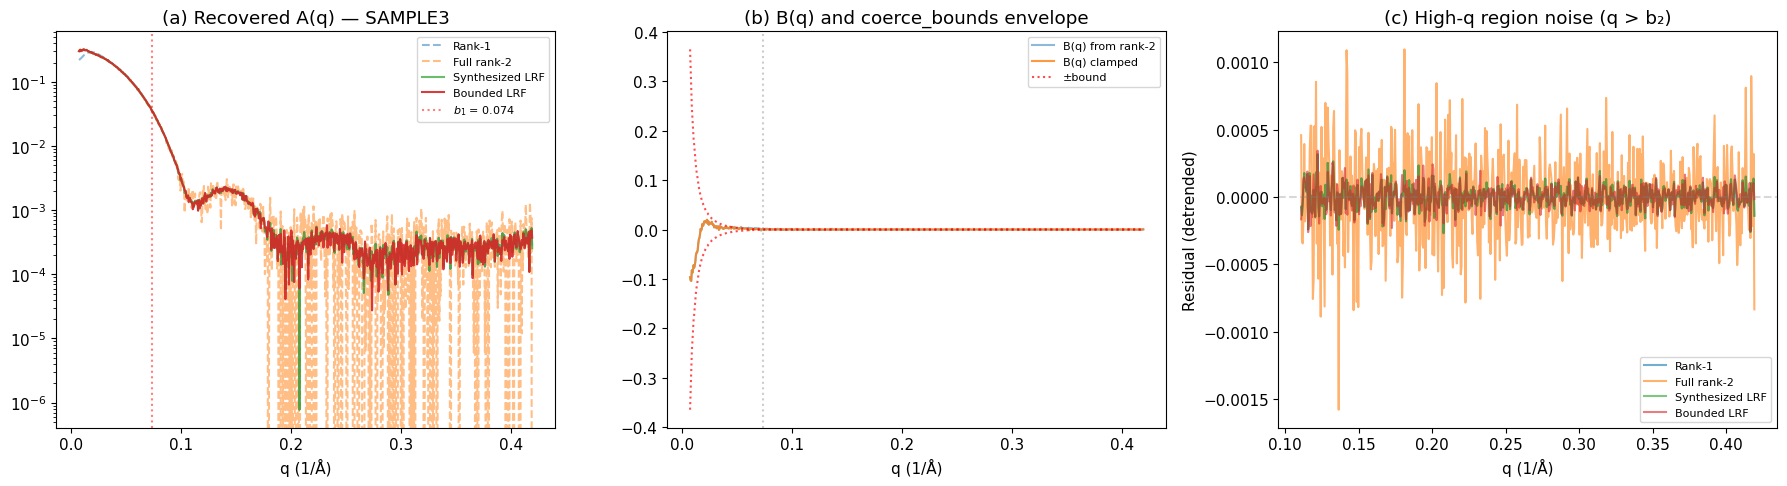

In [12]:
# --- Visualise real-data results ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

methods_real = [
    (A_r1_real, 'Rank-1', '--', 0.5),
    (A_r2_real, 'Full rank-2', '--', 0.5),
    (A_synth_real, 'Synthesized LRF', '-', 0.7),
    (A_bd_real, 'Bounded LRF', '-', 0.9),
]

# (a) Recovered A(q) on log scale
ax = axes[0]
ax.set_title("(a) Recovered A(q) — SAMPLE3")
ax.set_yscale('log')
for A, label, ls, alpha in methods_real:
    ax.plot(q_real, A, ls, alpha=alpha, label=label)
ax.axvline(b1_real, ls=':', color='red', alpha=0.5, label=f'$b_1$ = {b1_real:.3f}')
ax.set_xlabel('q (1/Å)')
ax.legend(fontsize=8)

# (b) B(q) and the bounding envelope
ax = axes[1]
ax.set_title("(b) B(q) and coerce_bounds envelope")
ax.plot(q_real, B_r2_real, alpha=0.5, label='B(q) from rank-2')
ax.plot(q_real, B_clamp_real, alpha=0.8, label='B(q) clamped')
ax.plot(q_real, bq_bound_real, ':', color='red', alpha=0.7, label='±bound')
ax.plot(q_real, -bq_bound_real, ':', color='red', alpha=0.7)
ax.axvline(b1_real, ls=':', color='gray', alpha=0.4)
ax.set_xlabel('q (1/Å)')
ax.legend(fontsize=8)

# (c) High-q noise comparison
q_high = q_real > b2_real
if q_high.sum() > 10:
    ax = axes[2]
    ax.set_title("(c) High-q region noise (q > b₂)")
    from scipy.signal import savgol_filter
    win = min(51, q_high.sum()//2*2+1)
    smooth_r1 = savgol_filter(A_r1_real[q_high], win, 3)
    smooth_r2 = savgol_filter(A_r2_real[q_high], win, 3)
    smooth_syn = savgol_filter(A_synth_real[q_high], win, 3)
    smooth_bd = savgol_filter(A_bd_real[q_high], win, 3)
    for A, sm, label in [(A_r1_real, smooth_r1, 'Rank-1'),
                          (A_r2_real, smooth_r2, 'Full rank-2'),
                          (A_synth_real, smooth_syn, 'Synthesized LRF'),
                          (A_bd_real, smooth_bd, 'Bounded LRF')]:
        ax.plot(q_real[q_high], A[q_high] - sm, alpha=0.6, label=label)
    ax.axhline(0, color='gray', ls='--', alpha=0.3)
    ax.set_xlabel('q (1/Å)')
    ax.set_ylabel('Residual (detrended)')
    ax.legend(fontsize=8)

fig.tight_layout()

Guinier Rg from SAMPLE3 (q < 0.0394):
  Rank-1:          25.34 Å
  Full rank-2:     33.50 Å
  Synthesized LRF: 33.49 Å
  Bounded LRF:     33.50 Å

Note: b1 = 0.0737 is above the Guinier limit 0.0394


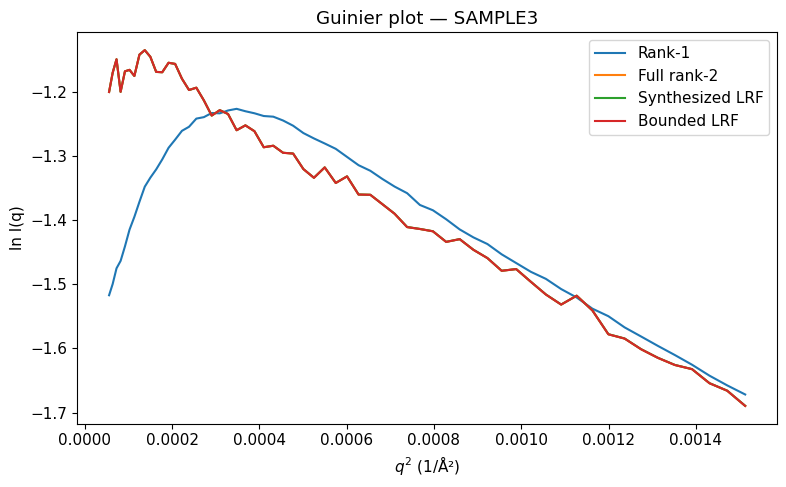

In [13]:
# --- Guinier analysis on real data ---
q_guinier_max_real = 1.3 / Rg_est
mask_g_real = (q_real < q_guinier_max_real) & (q_real > 0)

rg_r1 = guinier_rg(q_real[mask_g_real], A_r1_real[mask_g_real])
rg_r2 = guinier_rg(q_real[mask_g_real], A_r2_real[mask_g_real])
rg_syn = guinier_rg(q_real[mask_g_real], A_synth_real[mask_g_real])
rg_bd = guinier_rg(q_real[mask_g_real], A_bd_real[mask_g_real])

print(f"Guinier Rg from SAMPLE3 (q < {q_guinier_max_real:.4f}):")
print(f"  Rank-1:          {rg_r1:.2f} Å")
print(f"  Full rank-2:     {rg_r2:.2f} Å")
print(f"  Synthesized LRF: {rg_syn:.2f} Å")
print(f"  Bounded LRF:     {rg_bd:.2f} Å")
print(f"\nNote: b1 = {b1_real:.4f} is {'below' if b1_real < q_guinier_max_real else 'above'} "
      f"the Guinier limit {q_guinier_max_real:.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.set_title("Guinier plot — SAMPLE3")
for vals, label in [(A_r1_real, 'Rank-1'), (A_r2_real, 'Full rank-2'),
                     (A_synth_real, 'Synthesized LRF'), (A_bd_real, 'Bounded LRF')]:
    m = mask_g_real & (vals > 0)
    ax.plot(q_real[m]**2, np.log(vals[m]), label=label)
ax.set_xlabel('$q^2$ (1/Å²)')
ax.set_ylabel('ln I(q)')
ax.legend()
fig.tight_layout()

In [14]:
# --- Reconstruction quality: ||M - P_recovered @ C|| ---

# Rank-1
M_hat_r1 = A_r1_real.reshape(-1, 1) @ C1_real
err_r1 = np.linalg.norm(M_peak - M_hat_r1) / np.linalg.norm(M_peak)

# Full rank-2
M_hat_r2 = P_r2_real @ C2_real
err_r2 = np.linalg.norm(M_peak - M_hat_r2) / np.linalg.norm(M_peak)

# Synthesized LRF (uses rank-2 B at low q, but A is blended)
P_syn = np.column_stack([A_synth_real, B_r2_real])
M_hat_syn = P_syn @ C2_real
err_syn = np.linalg.norm(M_peak - M_hat_syn) / np.linalg.norm(M_peak)

# Bounded LRF (uses clamped B and redistributed A)
P_bd = np.column_stack([A_bd_real, B_clamp_real])
M_hat_bd = P_bd @ C2_real
err_bd = np.linalg.norm(M_peak - M_hat_bd) / np.linalg.norm(M_peak)

print(f"Reconstruction error (relative Frobenius norm):")
print(f"  Rank-1:          {err_r1:.4f}  ({err_r1*100:.2f}%)")
print(f"  Full rank-2:     {err_r2:.4f}  ({err_r2*100:.2f}%)")
print(f"  Synthesized LRF: {err_syn:.4f}  ({err_syn*100:.2f}%)")
print(f"  Bounded LRF:     {err_bd:.4f}  ({err_bd*100:.2f}%)")

# High-q noise measure
std_r1 = np.std(A_r1_real[q_high] - smooth_r1)
std_r2 = np.std(A_r2_real[q_high] - smooth_r2)
std_syn = np.std(A_synth_real[q_high] - smooth_syn)
std_bd = np.std(A_bd_real[q_high] - smooth_bd)
print(f"\nHigh-q noise (std of detrended residual, q > b₂):")
print(f"  Rank-1:          {std_r1:.6f}")
print(f"  Full rank-2:     {std_r2:.6f}")
print(f"  Synthesized LRF: {std_syn:.6f}")
print(f"  Bounded LRF:     {std_bd:.6f}")
print(f"\nNoise ratios relative to full rank-2:")
print(f"  Synthesized: {std_syn/std_r2:.3f}  (↓ {(1-std_syn/std_r2)*100:.1f}%)")
print(f"  Bounded:     {std_bd/std_r2:.3f}  (↓ {(1-std_bd/std_r2)*100:.1f}%)")

Reconstruction error (relative Frobenius norm):
  Rank-1:          0.0381  (3.81%)
  Full rank-2:     0.0328  (3.28%)
  Synthesized LRF: 0.0330  (3.30%)
  Bounded LRF:     0.0328  (3.28%)

High-q noise (std of detrended residual, q > b₂):
  Rank-1:          0.000083
  Full rank-2:     0.000318
  Synthesized LRF: 0.000083
  Bounded LRF:     0.000085

Noise ratios relative to full rank-2:
  Synthesized: 0.259  (↓ 74.1%)
  Bounded:     0.268  (↓ 73.2%)


---
## Summary

| Aspect | Rank-1 | Full Rank-2 | Synthesized LRF | Bounded LRF |
|--------|--------|-------------|-----------------|-------------|
| Low-q correction | ✗ | ✓ | ✓ | ✓ |
| High-q noise | Best | Worst | ≈ Rank-1 | ≈ Rank-1 |
| Guinier Rg | Biased low | Best | = Full rank-2 | = Full rank-2 |
| Mechanism | Single component | Two components, no constraint | Splice two decompositions | Clamp B(q) within envelope |
| Parameters | None | None | $b_1$ from Rg | $L$ fitted from B(q) shape |

### Key algorithmic distinction

- **Synthesized LRF** performs **two independent decompositions** (rank-1 and rank-2) and
  blends them with a logistic weight $w(q)$ around $b_1 = \pi/R$.
- **Bounded LRF** performs **one rank-2 decomposition**, then applies the physics-derived
  envelope $|B(q)| \leq A(q)/(c_1(qLR)^2)$ from $|\Phi(x)| \leq 3/x^2$. Excess B(q) is
  redistributed into A(q) to preserve the total signal at the peak frame.

### Bound derivation recap

$$\Phi(x) = \frac{3(\sin x - x\cos x)}{x^3} \implies |\Phi(x)| \leq \frac{3}{x^2}$$

With $x = 2qLR$: $|B(q)/A(q)| = |K\Phi(2qLR)| \lesssim 1/(qLR)^2$ (constants absorbed into $L$).